LIBRERIE 

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
import sys
from scipy.io import savemat
from datetime import datetime
import scipy.sparse as sp       # Used for efficient graph Laplacian matrix operations
import trimesh                  # Library for loading and processing 3D meshes (STL)
from scipy.spatial import cKDTree # Spatial tree structure for fast nearest-neighbor search


SEMPLIFICAZIONE GEOMETRIA E VOXELIZZAZIONE

In [12]:
def setup_voxel_graph(filename, pitch, target_scale=100.0):
    """
    Loads an STL mesh, converts it into a volumetric voxel graph for physics,
    and computes interpolation weights for visualization.
    
    Args:
        filename (str): Path to the .stl file.
        pitch (float): Voxel size/resolution. Determines density of physical nodes.
        target_scale (float): Normalization scale for the mesh (default: 100.0).
        
    Returns:
        visual_mesh: The original trimesh object.
        phys_nodes: Array (N, 3) of physical node coordinates (centers of voxels).
        L: Sparse Matrix (N, N), the Graph Laplacian operator.
        indices: Array (M, 4), indices of 4 nearest physical nodes for each visual vertex.
        weights: Array (M, 4), interpolation weights for skinning.
    """
    print(f"Loading {filename}...")
    
    # 1. Load Visual Mesh (The "Skin" of the muscle)
    # This mesh is used only for visualization, not for physics calculation.
    visual_mesh = trimesh.load(filename)
    
    # Mesh Simplification
    # Reduces the number of triangles to improve performance in Matplotlib.
    target_faces = 2500 
    if visual_mesh.faces.shape[0] > target_faces:
        print(f"Mesh too complex ({visual_mesh.faces.shape[0]} faces). Simplifying to ~{target_faces}...")
        try:
            # Quadratic decimation preserves the shape while reducing face count.
            visual_mesh = visual_mesh.simplify_quadratic_decimation(target_faces)
            print(f"Simplification successful: {visual_mesh.faces.shape[0]} faces.")
        except Exception as e:
            print(f"Warning: Mesh simplification failed ({e}). Visualization might be slow.")

    # Scaling
    # Normalizes the mesh size to a target scale (100 units) to ensure numerical stability for physics.
    scale_factor = target_scale / visual_mesh.extents.max()
    visual_mesh.apply_scale(scale_factor)
    
    # 2. Physical Voxelization 
    print(f"Physical Voxelization (Pitch={pitch})...")
    # Creates a grid of solid voxels inside the mesh volume.
    # 'pitch' determines the distance between nodes (resolution).
    voxel_grid = visual_mesh.voxelized(pitch=pitch)
    
    # Extract the center points of the voxels. These act as the mass particles for the simulation.
    phys_nodes = voxel_grid.points
    print(f"Generated {len(phys_nodes)} physical nodes.")
    
    # 3. Graph Construction (Defining Connectivity/Topology)
    # Uses a KDTree to find neighboring particles within a specific radius.
    tree = cKDTree(phys_nodes)
    
    # Connection radius: pitch * 1.5 ensures connectivity with diagonals (structural stability).
    radius = pitch * 1.5
    pairs = tree.query_pairs(r=radius)
    edges = np.array(list(pairs))
    
    # Build the Sparse Adjacency Matrix and Laplacian
    # Create row and col indices for bidirectional connections (undirected graph).
    row = np.concatenate([edges[:, 0], edges[:, 1]])
    col = np.concatenate([edges[:, 1], edges[:, 0]])
    data = np.ones(len(row))
    
    num_phys = len(phys_nodes)
    # Sparse Coordinate Matrix representing the graph connectivity (1 if connected, 0 otherwise).
    A = sp.coo_matrix((data, (row, col)), shape=(num_phys, num_phys))
    
    # Degree Matrix (D): Diagonal matrix where D_ii is the number of neighbors for node i.
    degrees = np.array(A.sum(axis=1)).flatten()
    degrees[degrees == 0] = 1 # Avoid division by zero for isolated nodes
    D = sp.diags(degrees)
    
    # Graph Laplacian (L = D - A).
    # This matrix operator approximates the spatial second derivative (divergence of gradient).
    L = D - A
    
    # 4. Compute Skinning Weights (Binding Visual Mesh to Physics Nodes)
    print("Computing Skinning weights...")
    # Find the 4 closest physical nodes for every vertex of the visual mesh.
    dist, indices = tree.query(visual_mesh.vertices, k=4)
    
    # Inverse Distance Weighting: Closer nodes have more influence on the vertex movement.
    weights = 1.0 / (dist + 1e-8) # Add epsilon to avoid division by zero
    
    # Normalize weights so they sum to 1.0.
    weights /= weights.sum(axis=1)[:, np.newaxis]
    
    return visual_mesh, phys_nodes, L.tocsr(), indices, weights

EQUAZIONE CAUCHY E RUNGE-KUTTA

In [13]:
class WaveGNN3D:
    """
    Graph Neural Network for 3D Soft Body Deformation (Cauchy Momentum).
    Integrates spatial derivatives (via Laplacian Matrix) and time integration.
    """
    def __init__(self, laplacian_matrix, fixed_mask, c, k, dt, integrator='rk4'):
        """
        Args:
            laplacian_matrix: Sparse matrix (N, N) encoding the graph topology.
            fixed_mask: Boolean array identifying nodes that cannot move (boundary conditions).
            c: Wave speed (related to Stiffness/Young's Modulus).
            k: Damping coefficient (related to Viscosity).
            dt: Time step for integration.
            integrator: Numerical integration method ('rk4' or 'euler').
        """
        self.L = laplacian_matrix
        self.fixed_mask = fixed_mask
        self.c = c
        self.k = k
        self.dt = dt
        self.integrator = integrator
        
    def compute_laplacian(self, u):
        """
        Computes the Graph Laplacian: L * u.
        Represents the discrete divergence of stress on the graph.
        
        Args:
            u: Node displacements, shape (N, 3).
            
        Returns:
            laplacian: shape (N, 3).
        """
        # Sparse matrix multiplication. Efficiently computes sum(u_neighbors) - degree * u_i.
        return self.L.dot(u)
    
    def get_acc(self,u_t, v_t, force):
        """
        Computes the acceleration from constant force 
        Args:
            u_t:
            v_t:
            force:
        Returns:
            dv_dt
        """
        lap = self.compute_laplacian(u_t)
        # -lap is used because the restoring force opposes the displacement relative to neighbors.
        
        return (self.c**2 * -lap) - (self.k * v_t) + force
    
    def update_euler(self,node_features):
        
        
        """
        Node update function using Euler time integration.
        
        Args:
            node_features: Current [vx, vy, vz, fx, fy, fz] for each node, shape (Nx, Ny, Nz, 9)
            
        Returns:
            new_features: Updated [vx, vy, vz, fx, fy, fz] for each node, shape (Nx, Ny, Nz, 9)
        """
        
        #Extract current state
        u = node_features[:, :,  0] #current position of all nodes
        v = node_features[:, :,  1] #current velocity of all nodes 
        force_ext = node_features[:, :, 2] #current external forces influence all nodes
        
        #get_derivatives u,v,force_ext
        dv_dt = self.get_acc(u,v,force_ext)
        
        #Compute acceleration from wave equation
        
        #Euler time integration
        v_new = v + self.dt * dv_dt
        
        #Semi-Implicit Euler Method:
        #in our case in theory we should substitute v_new with du_dt=v but in our case it gives us numerical explosion
        #but we can resolve problem applying directly new velocity estimation v_new to update the position. This can preserve system energy
        u_new = u + self.dt * v_new 

        force_new = force_ext

        #Enforce boundary conditions (all edges fixed)
        
        u_new[self.fixed_mask] = 0.0
        v_new[self.fixed_mask] = 0.0
        
        # Stack back into features
        new_features = np.stack([u_new, v_new, force_new], axis=2)
        
        return new_features
    
    
    def update_rk4(self, node_features):
        """
        Performs one time step using Runge-Kutta 4th order integration.
        
        Args:
            node_features: Current state [u, v, f], shape (N, 3, 3).
            
        Returns:
            new_features: Updated state [u, v, f] at t + dt.
        """
        # Extract current state (Displacement, Velocity, External Force)
        u = node_features[:, :, 0]
        v = node_features[:, :, 1]
        force = node_features[:, :, 2]
        
        # Define the acceleration function (Cauchy Momentum Equation):
        # a = (1/rho) * (Elastic_Force + Viscous_Force + External_Force)
        # Here, Elastic_Force is approximated by -c^2 * Laplacian(u)
       
        
        # RK4 Integration Steps (k1, k2, k3, k4)

        #First Step
        k1_v = self.get_acc(u, v,force)
        k1_u = v

        #Update u_t,v_t first step
        u_t_1= u + 0.5*self.dt*k1_u
        v_t_1= v + 0.5*self.dt*k1_v

        k2_v = self.get_acc(u_t_1,v_t_1,force)
        k2_u = v + 0.5*self.dt*k1_v

        #Update u_t,v_t second step
        u_t_2=u + 0.5*self.dt*k2_u
        v_t_2= v + 0.5*self.dt*k2_v
        
        k3_v = self.get_acc(u_t_2,v_t_2,force)
        k3_u = v + 0.5*self.dt*k2_v
        
        #Update u_t,v_t third step

        u_t_3=u + self.dt*k3_u
        v_t_3=v + self.dt*k3_v

        k4_v = self.get_acc(u_t_3,v_t_3,force )
        k4_u = v + self.dt*k3_v
        
        # Weighted average of slopes to update state
        u_new = u + (self.dt / 6.0) * (k1_u + 2*k2_u + 2*k3_u + k4_u)
        v_new = v + (self.dt / 6.0) * (k1_v + 2*k2_v + 2*k3_v + k4_v)

        # Apply Boundary Conditions (Dirichlet)
        # Set velocity and displacement to 0 for fixed nodes (tendons).
        u_new[self.fixed_mask] = 0.0
        v_new[self.fixed_mask] = 0.0
        
        # Force remains constant
        force_new = force
        return np.stack([u_new, v_new, force_new], axis=2)
    
    def forward(self, node_features): 
        """
        Executes the forward pass of the GNN solver.
        """  
        if self.integrator == 'rk4':
            new_features = self.update_rk4(node_features)
        elif self.integrator== "euler":
            new_features = self.update_euler(node_features)
        return new_features

SIMULAZIONE

In [14]:
def simulate_wave_3d(gnn, u0, v0, f0, visual_mesh, skin_idx, skin_w, steps, force_duration):
    """
    Simulate 3D soft body deformation using GNN.
    
    Args:
        gnn: WaveGNN3D instance (contains physics rules, L matrix, dt)
        u0: Initial displacements of physical nodes, shape (N_phys, 3)
        v0: Initial velocities of physical nodes, shape (N_phys, 3)
        f0: Initial external forces on physical nodes, shape (N_phys, 3)
        visual_mesh: The high-resolution Trimesh object (The "Skin")
        skin_idx: Indices of 4 nearest physical nodes for each visual vertex, shape (M_visual, 4)
        skin_w: Interpolation weights for skinning, shape (M_visual, 4)
        steps: Total number of simulation time steps (int)
        force_duration: Number of steps the external force remains active (int)
        
    Returns:
        visual_history: List of deformed visual mesh vertices over time.
                        Length of list: steps // 2 (due to downsampling).
                        Shape of each element: (M_visual, 3).
    """
    # Initialize node features
    features = np.stack([u0, v0, f0], axis=2) 
    visual_history = []
    
    print(f"Running simulation for {steps} steps...")
    
    for step in range(steps):
        # Impulse logic: Remove external force after a certain duration
        if step == force_duration:
            features[:, :, 2] = 0.0 
            
        # 1. Physics Step: Advance the voxel simulation by one time step
        features = gnn.forward(features)
        
        # 2. Visualization/Saving Step
        # Downsample: Save every 2nd frame to save memory and make animation faster.
        if step % 2 == 0:
            # Extract physical displacement from the physics engine
            u_phys = features[:, :, 0]
            
            # Skinning: Interpolate physical displacement to visual mesh vertices.
            # Formula: Visual_Disp = Sum(Neighbor_Phys_Disp * Weight)
            weighted_disp = (u_phys[skin_idx] * skin_w[:, :, np.newaxis]).sum(axis=1)
            
            # Compute final visual position = Rest Position + Interpolated Displacement
            current_visual_verts = visual_mesh.vertices + weighted_disp
            visual_history.append(current_visual_verts)
            
            if step % 50 == 0: print(f"Step {step}/{steps}...")
                
    return visual_history

IMPOSTAZIONE PARAMETRI E VISUALIZZAZIONE

Loading Prototipo_Muscolo Stern_DX.stl...
Mesh too complex (10802 faces). Simplifying to ~2500...
Physical Voxelization (Pitch=4.0)...
Generated 405 physical nodes.
Computing Skinning weights...
Muscle main axis detected: Y
Parameters:
  Nodes = 405
  Fixed Nodes (Tendons) = 76
  Forced Nodes (Belly) = 93
  Force Direction = [ 0.  0. 50.]
Running simulation...
Running simulation for 250 steps...
Step 0/250...
Step 50/250...
Step 100/250...
Step 150/250...
Step 200/250...
Simulation complete in 0:00:00.233030
Creating 3D surface animation...
Saved: muscle_sim.gif


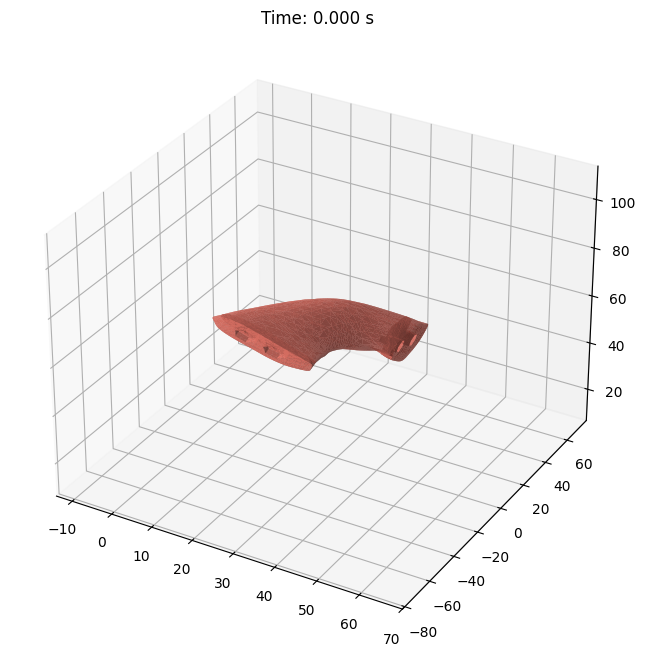

In [15]:

# Redirect stdout to capture terminal output
class Logger:
    def __init__(self, filename):
        self.terminal = sys.stdout
        self.log = open(filename, "w")
    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)
    def flush(self):
        self.terminal.flush()
        self.log.flush()
    def close(self):
        self.log.close()

if __name__ == "__main__":
    
    # Start logging
    logger = Logger("simulation_output_3d.txt")
    sys.stdout = logger

    # ============================================================================
    # Setup and Simulation
    # ============================================================================

    # Parameters
    filename = "Prototipo_Muscolo Stern_DX.stl" 
    
    # Geometry Resolution
    PITCH = 4.0        # Voxel size in mm. Controls the density of physical nodes.
    
    # Physics Parameters (Calibrated for Realistic Muscle)
    DT = 0.005         # Time step (seconds). Small enough to maintain numerical stability.
    STIFFNESS = 2.0   # Elastic modulus. Controls resistance to deformation.
    DAMPING = 0.05     # Viscosity. Controls how fast oscillations decay.
    
    # Simulation Duration
    STEPS = 250        # Total simulation steps
    FORCE_DUR = 50     # Duration of the initial impact force
    
    # 1. Setup Geometry (Voxelization + Skinning)
    visual_mesh, phys_nodes, L, skin_idx, skin_w = setup_voxel_graph(filename, PITCH)
    num_nodes = len(phys_nodes)

    # 2. Initial Conditions (Displacement, Velocity, Force)
    u0 = np.zeros((num_nodes, 3))
    v0 = np.zeros((num_nodes, 3))
    f0 = np.zeros((num_nodes, 3))

    # 3. Boundary Conditions & Forces (Anatomy-aware)
    
    # Detect the main longitudinal axis of the muscle (X, Y, or Z)
    extent = phys_nodes.max(axis=0) - phys_nodes.min(axis=0)
    long_axis = np.argmax(extent) 
    axis_names = ['X', 'Y', 'Z']
    print(f"Muscle main axis detected: {axis_names[long_axis]}")
    
    # Extract coordinates along the long axis
    coords = phys_nodes[:, long_axis]
    min_coord = coords.min()
    max_coord = coords.max()
    length = max_coord - min_coord
    
    # FIX TENDONS: Identify nodes at the top/bottom 10% of the muscle length.
    tendon_limit = length * 0.10
    fixed_mask = (coords < (min_coord + tendon_limit)) | (coords > (max_coord - tendon_limit))
    
    # FORCE APPLICATION: Target the center of the muscle.
    muscle_center = np.mean(phys_nodes, axis=0)
    
    # Select nodes within a radius (15% of length) from the center.
    dist_from_center = np.linalg.norm(phys_nodes - muscle_center, axis=1)
    force_mask = dist_from_center < (length * 0.15)

    # Define Force Vector: Perpendicular to the long axis.
    force_vec = np.zeros(3)
    punch_axis = (long_axis + 1) % 3 
    force_vec[punch_axis] = 50.0 # Force magnitude
    
    # Apply force to selected nodes
    f0[force_mask] = force_vec
    
    print("Parameters:")
    print(f"  Nodes = {num_nodes}")
    print(f"  Fixed Nodes (Tendons) = {np.sum(fixed_mask)}")
    print(f"  Forced Nodes (Belly) = {np.sum(force_mask)}")
    print(f"  Force Direction = {force_vec}")

    integrator="rk4" # "euler" or "rk4"
    # 4. Initialize GNN Model
    gnn = WaveGNN3D(L, fixed_mask, STIFFNESS, DAMPING, DT, integrator=integrator)

    # 5. Run Simulation Loop
    print("Running simulation...")
    start_time = datetime.now()
    visual_history = simulate_wave_3d(gnn, u0, v0, f0, visual_mesh, skin_idx, skin_w, 
                                    steps=STEPS, force_duration=FORCE_DUR)
    end_time = datetime.now()
    print(f"Simulation complete in {end_time - start_time}")

    # ============================================================================
    # Visualization (3D Animation)
    # ============================================================================

    print("Creating 3D surface animation...")
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Setup Plot Limits dynamically based on mesh size
    all_verts = visual_mesh.vertices
    margin = 30
    ax.set_xlim(all_verts[:,0].min()-margin, all_verts[:,0].max()+margin)
    ax.set_ylim(all_verts[:,1].min()-margin, all_verts[:,1].max()+margin)
    ax.set_zlim(all_verts[:,2].min()-margin, all_verts[:,2].max()+margin)
    ax.set_title(f'Muscle Deformation (Force on {axis_names[punch_axis]})')

    def animate(frame):
        ax.clear()
        # Reset limits (required for each frame in Matplotlib 3D)
        ax.set_xlim(all_verts[:,0].min()-margin, all_verts[:,0].max()+margin)
        ax.set_ylim(all_verts[:,1].min()-margin, all_verts[:,1].max()+margin)
        ax.set_zlim(all_verts[:,2].min()-margin, all_verts[:,2].max()+margin)
        ax.set_title(f"Time: {frame * DT * 2:.3f} s")
        
        # Get deformed vertices for the current frame
        verts_now = visual_history[frame]
        
        # Plot the surface
        ax.plot_trisurf(verts_now[:,0], verts_now[:,1], verts_now[:,2], triangles=visual_mesh.faces,
                        color='salmon', alpha=0.9, edgecolor='none', shade=True)
        return fig,

    # Generate and Save Animation
    anim = FuncAnimation(fig, animate, frames=len(visual_history), interval=40)

    if integrator=="euler":
        anim.save('muscle_sim_euler.gif', writer='pillow', fps=60)
    else:
        anim.save('muscle_sim_rk4.gif', writer='pillow', fps=60)
        
    print("Saved: muscle_sim.gif")
    
    # Close logger
    sys.stdout = logger.terminal
    logger.close()